## Setup

In [32]:
#Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set up connection to sql database
conn = sqlite3.connect("db.sqlite3")

# Make a sql query, taking specific box score stats and adding on team date from another table
query = """
SELECT 
    tg.game_id,
    tg.team_id,
    tg.is_home,
    tg.possessions,
    tg.pace,
    tg.fg_made,
    tg.fg_attempted,
    tg.two_pt_made,
    tg.two_pt_attempted,
    tg.three_pt_made,
    tg.three_pt_attempted,
    tg.three_pt_pct,
    tg.ft_made,
    tg.ft_attempted,
    tg.ft_rate,
    tg.points,
    tg.assists,
    tg.steals,
    tg.blocks,
    tg.turnovers,
    tg.reb_offensive,
    tg.reb_defensive,
    tg.reb_total,
    tg.fouls_total,
    tg.fouls_technical,
    tg.fouls_flagrant,
    tg.points_fast_break,
    tg.rating,
    tg.points_in_paint,
    tg.game_score,
    tg.largest_lead,
    tg.oreb_pct,
    g.start_date AS game_date,
    g.season,
    CASE
        WHEN tg.is_home = 1 THEN g.home_conference_id
        ELSE g.away_conference_id
    END AS conference_id
FROM opencourt_gameteamstats tg
JOIN opencourt_game g
    ON tg.game_id = g.id
"""

# Read in the data
df = pd.read_sql(query, conn)

# Sort by date and by team
df = df.dropna()
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values(['team_id', 'game_date'])
# Test for first 4 rows
df.head(4)


,game_id,team_id,is_home,possessions,pace,fg_made,fg_attempted,two_pt_made,two_pt_attempted,three_pt_made,...,fouls_flagrant,points_fast_break,rating,points_in_paint,game_score,largest_lead,oreb_pct,game_date,season,conference_id
11520,5864,1,0,69.0,69.0,26.0,57.0,21.0,39.0,5.0,...,0.0,3.0,92.8,32.0,38.2,18.0,22.9,2023-11-07 02:00:00,2024,30.0
11718,5947,1,0,63.0,64.0,20.0,57.0,15.0,40.0,5.0,...,0.0,13.0,101.6,28.0,42.0,1.0,44.4,2023-11-11 00:00:00,2024,30.0
12078,6143,1,1,74.0,73.0,23.0,60.0,18.0,41.0,5.0,...,0.0,9.0,100.0,28.0,45.9,9.0,40.0,2023-11-15 01:00:00,2024,30.0
13521,6867,1,0,73.0,73.0,25.0,55.0,17.0,38.0,8.0,...,0.0,7.0,97.3,32.0,51.9,7.0,24.0,2023-11-30 01:00:00,2024,30.0


In [33]:
# Made a manual conference mapping to map the conference id to its specific ranking, 
# It is definitely not the best choice but It is the simplest method I can think of due to some
# of the limitation of the api

conf_mapping = {
    1: 7, 2: 4, 3: 24, 4: 29, 5: 10, 6: 2, 7: 5,
    8: 16, 9: 21, 10: 3, 11: 14, 12: 15, 13: 13,
    14: 19, 15: 12, 16: 25, 17: 17, 18: 31, 19: 9,
    20: 6, 21: 28, 22: 26, 23: 27, 24: 1, 25: 30,
    26: 23, 27: 18, 28: 22, 29: 20, 30: 11,
    31: 8, 32: 32, 33: 32, 34: 32
}

df['conf_ranking'] = df['conference_id'].map(conf_mapping)


In [34]:
GAME_DATA_LIMIT = False

# Point differential
df['point_diff'] = df['points'] - np.nan  # Placeholder for opponent points, will merge later

# Offensive efficiency (points / possessions)
df['off_eff'] = df['points'] / df['possessions'].replace(0, np.nan)

# Offensive rebounds per possession
df['orr_eff'] = df['reb_offensive'] / df['possessions'].replace(0, np.nan)

# Turnover rate
df['turnover_rate'] = df['turnovers'] / df['possessions'].replace(0, np.nan)

# Effective FG%
df['efg_pct'] = (df['fg_made'] + 0.5 * df['three_pt_made']) / df['fg_attempted'].replace(0, np.nan)

# Assist turnover ratio
df['ato_rto'] = df['assists'] / df['turnovers']

# Get the opposition points in order to calculate differential for classification
opp_df = df[['game_id', 'team_id', 'points']].rename(columns={'team_id':'opp_team_id', 'points':'opp_points'})
df = df.merge(opp_df, on='game_id')
df = df[df['team_id'] != df['opp_team_id']]  # exclude same team
df['point_diff'] = df['points'] - df['opp_points']

# Group by team
group = df.groupby(['team_id', 'season']) # Added 'season' with brackets

df['games_played'] = group.cumcount() # find the amount of games played for each team

# Rolling stats: mean of all previous games (shift=1 avoids leakage)
df['avg_ftr'] = group['ft_rate'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_turnover_rate'] = group['turnover_rate'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df['avg_efg_pct'] = group['efg_pct'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_point_diff'] = group['point_diff'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_pace'] = group['pace'].transform(
    lambda x: x.shift(1).expanding().mean()
)
df['avg_oreb_pct'] = group['oreb_pct'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_rating'] = group['rating'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_ato_rto'] = group['ato_rto'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_largest_lead'] = group['largest_lead'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['avg_blocks'] = group['blocks'].transform(
    lambda x: x.shift(1).expanding().mean()
)

# Last 5 point differential
df['L5_point_diff'] = group['point_diff'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df = df[df['avg_efg_pct'].notna()]  # Remove first game of each team
 
df_a = df.copy()
df_b = df.copy()

matchups = df_a.merge(
    df_b,
    on='game_id',
    suffixes=('_a', '_b')
)

# Keep one row per matchup
matchups = matchups[matchups['team_id_a'] < matchups['team_id_b']]

# Feature differences
matchups['diff_turnover_rate'] = matchups['avg_turnover_rate_a'] - matchups['avg_turnover_rate_b']
matchups['diff_efg_pct'] = matchups['avg_efg_pct_a'] - matchups['avg_efg_pct_b']
matchups['diff_point_diff'] = matchups['avg_point_diff_a'] - matchups['avg_point_diff_b']
matchups['diff_pace'] = matchups['avg_pace_a'] - matchups['avg_pace_b']
matchups['diff_avg_ftr'] = matchups['avg_ftr_a'] - matchups['avg_ftr_b']
matchups['diff_avg_oreb_pct'] = matchups['avg_oreb_pct_a'] - matchups['avg_oreb_pct_b']
matchups['diff_avg_ato_rto'] = matchups['avg_ato_rto_a'] - matchups['avg_ato_rto_b']
matchups['diff_avg_blocks'] = matchups['avg_blocks_a'] - matchups['avg_blocks_b']
matchups['diff_avg_rating'] = matchups['avg_rating_a'] - matchups['avg_rating_b']
matchups['home_advantage'] = matchups['is_home_a'] - matchups['is_home_b']

matchups['team_a_win'] = (matchups['points_a'] > matchups['points_b']).astype(int)

matchups['diff_L5_point_diff'] = matchups['L5_point_diff_a'] - matchups['L5_point_diff_b']

matchups['conf_rank_diff'] = matchups['conf_ranking_a'] - matchups['conf_ranking_b']

if GAME_DATA_LIMIT:
    matchups = matchups[(matchups['games_played_a'] >= 5) & (matchups['games_played_b'] >= 5)]

features = [
    'diff_efg_pct',
    'diff_turnover_rate',
    'diff_point_diff',
    'diff_pace',
    'diff_avg_ftr',
    'diff_avg_rating',
    'diff_avg_blocks',
    'diff_avg_oreb_pct',
    'diff_avg_ato_rto',
    'home_advantage',
]

X = matchups[features]
y = matchups['team_a_win']



In [35]:
#raise NotImplementedError

print(X.head())
print(y.head())

   diff_efg_pct  diff_turnover_rate  diff_point_diff  diff_pace  diff_avg_ftr  \
1     -0.023077            0.085038        -8.000000   1.000000      8.500000   
3      0.095640            0.008813         7.000000  -7.500000      0.550000   
5     -0.033606           -0.005092         0.733333  -1.633333     -0.286667   
7     -0.091133           -0.046759       -12.583333  -0.450000      5.975000   
9     -0.027802            0.015195         1.500000   0.877500     16.895000   

   diff_avg_rating  diff_avg_blocks  diff_avg_oreb_pct  diff_avg_ato_rto  \
1       -13.100000        -4.000000          -1.400000         -1.244444   
3        13.250000         0.000000         -13.300000          0.497504   
5        -5.366667        -2.133333           6.346667         -0.313362   
7        -7.075000        -1.666667           3.325000          0.213340   
9         3.860000        -1.650000           4.682500         -0.192817   

   home_advantage  
1              -1  
3               

In [ ]:
# Ensure matchup DataFrame has season column (carry it from df_a or df_b)
train_mask = matchups['game_date_a'] < '2025-04-16'

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[~train_mask].copy()
y_test = y[~train_mask].copy()

### XGBoost CLassifier Test

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

seed = np.random.randint(0, 10000)

xg_clas = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, colsample_bynode=0.8, random_state=seed)

xg_clas.fit(X_train, y_train)

preds = xg_clas.predict(X_test)
accuracy = accuracy_score(y_test, preds)
print(accuracy)


0.7840701219512195


<Axes: >

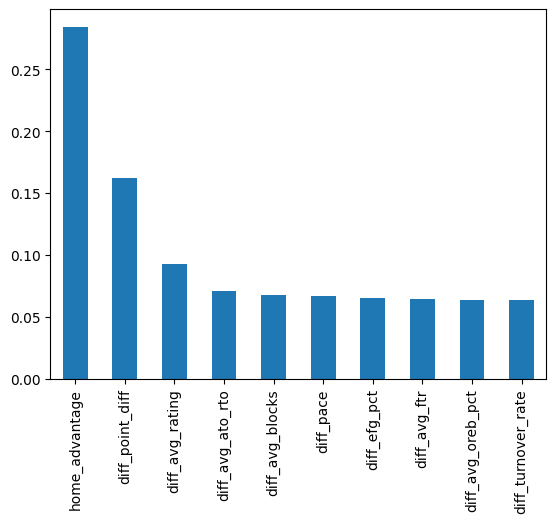

In [38]:
importances = pd.Series(xg_clas.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()

### Random Forest Classifier Test

In [39]:
from sklearn.ensemble import RandomForestClassifier

seed = np.random.randint(0, 10000)

RF_clas = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=seed)
RF_clas.fit(X_train, y_train)

y_pred = RF_clas.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


0.7314024390243903


<Axes: >

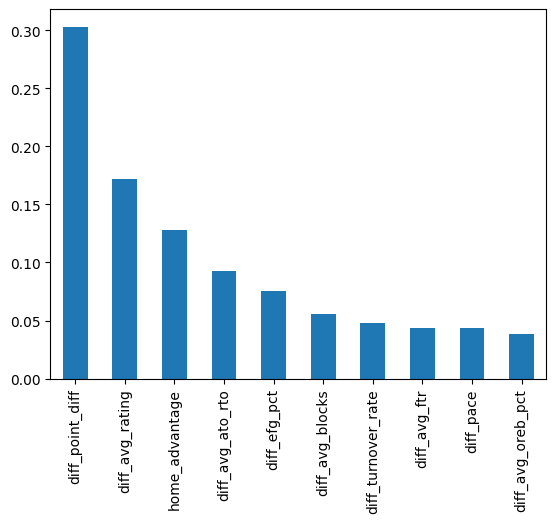

In [40]:
importances = pd.Series(RF_clas.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()

In [ ]:
"""
import joblib

joblib.dump(RF_clas, 'final_model')
"""


['final_model']